<a href="https://colab.research.google.com/github/czliu13-code/DataSci112/blob/main/DataSci_112_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Scrape Vienna Philharmonic Concert data from 1842-2026

import requests
import pandas as pd
import time
from bs4 import BeautifulSoup

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36',
    'X-Requested-With': 'XMLHttpRequest',
    'Referer': 'https://www.wienerphilharmoniker.at/en/konzert-archiv',
    'Accept': 'text/html, */*; q=0.01',
}

def parse_page(html):
    soup = BeautifulSoup(html, 'html.parser')
    rows = []
    for div in soup.find_all('div', class_='event-module'):
        d = div.attrs
        # detail URL
        a = div.find('a', href=True)
        detail_url = ('https://www.wienerphilharmoniker.at' + a['href']) if a else ''
        rows.append({
            'date':       d.get('data-date', ''),
            'title':      d.get('data-title', ''),
            'location':   d.get('data-location', ''),
            'composers':  d.get('data-composers', ''),
            'works':      d.get('data-works', ''),
            'performers': d.get('data-performers', ''),
            'detail_url': detail_url,
        })
    return rows

all_rows = []
MAX_PAGES = 12  # 10685 / 1000 = 11 pages

for page in range(1, MAX_PAGES + 1):
    url = f'https://www.wienerphilharmoniker.at/en/konzert-archiv/{page}'
    try:
        r = requests.get(url, headers=HEADERS, timeout=15)
        if r.status_code != 200:
            print(f'Page {page}: status {r.status_code} — stopping.')
            break
        rows = parse_page(r.text)
        if not rows:
            print(f'Page {page}: empty — stopping.')
            break
        all_rows.extend(rows)
        print(f'Page {page:>3} | +{len(rows):>2} → total {len(all_rows)}')
    except Exception as e:
        print(f'Page {page} error: {e}')
        break
    time.sleep(0.5)

print(f'\nDone. {len(all_rows)} total records.')

Page   1 | +1000 → total 1000
Page   2 | +1000 → total 2000
Page   3 | +1000 → total 3000
Page   4 | +1000 → total 4000
Page   5 | +1000 → total 5000
Page   6 | +1000 → total 6000
Page   7 | +1000 → total 7000
Page   8 | +1000 → total 8000
Page   9 | +1000 → total 9000
Page  10 | +1000 → total 10000
Page  11 | +686 → total 10686
Page 12: status 404 — stopping.

Done. 10686 total records.


In [ ]:
# Save scraped data to dataframe
df = pd.DataFrame(all_rows)
df['year'] = pd.to_datetime(df['date'], errors='coerce').dt.year
df.to_csv('wph_raw.csv', index=False)
print(f'Saved {len(df)} rows.')
print(df.head(3).to_string())

Saved 10686 rows.
         date                 title                         location                                                                                                                                              composers                                                                                                                                                                                                                                                                                                                                    works                                                                                                            performers                                                                  detail_url  year
0  1842-03-28  Philharmonic Concert  Hofburg Palace, Vienna, Austria  Ludwig van Beethoven;Luigi Cherubini;Ludwig van Beethoven;Ludwig van Beethoven;Wolfgang Amadeus Mozart;Anonymus;Luigi Cherubini;Ludwig van Beethoven;  Symphony No.

In [ ]:
import pandas as pd
df = pd.read_csv('wph_raw.csv')

In [ ]:
# Split both by semicolon
df['works_list'] = df['works'].fillna('').str.split(';')
df['composers_list'] = df['composers'].fillna('').str.split(';')

# Zip composer[i] → work[i] for each row, then flatten
records = []
for _, row in df.iterrows():
    works = [w.strip() for w in (row['works_list'] or []) if w.strip()]
    composers = [c.strip() for c in (row['composers_list'] or []) if c.strip()]
    for i, work in enumerate(works):
        composer = composers[i] if i < len(composers) else ''
        records.append({
            'date': row['date'],
            'year': row['year'],
            'title': row['title'],
            'location': row['location'],
            'performers': row['performers'],
            'detail_url': row['detail_url'],
            'work': work,
            'composer': composer,
        })

works_df = pd.DataFrame(records)
works_df[['date','year','composer','work']]

KeyError: 'works'

Scrape for violin concertos and composers.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

url = "https://en.wikipedia.org/wiki/List_of_compositions_for_violin_and_orchestra"

headers = {"User-Agent": "MyResearchBot/1.0 (contact: youremail@example.com)"}

time.sleep(1)
html = requests.get(url, headers=headers).text
soup = BeautifulSoup(html, "html.parser")

data = []

content = soup.find("div", class_="mw-parser-output")

# Loop through all top-level <ul> blocks
for ul in content.find_all("ul", recursive=False):
    # Loop through top-level <li> items (each should contain a composer)
    for li in ul.find_all("li", recursive=False):

        # Composer name is inside <a>
        a = li.find("a")
        if not a:
            continue

        composer = a.text.strip()

        # Nested <ul> contains the works
        nested = li.find("ul")
        if not nested:
            continue

        # Extract each work
        for work_li in nested.find_all("li", recursive=False):
            work = work_li.get_text(" ", strip=True)
            data.append([composer, work])

df = pd.DataFrame(data, columns=["Composer", "Work"])

df.to_csv("violin_concertos.csv", index = False)
df

from google.colab import files
files.download("violin_concertos.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Scrape for viola concertos and composers.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

url = "https://en.wikipedia.org/wiki/Viola_concerto"
headers = {"User-Agent": "MyResearchBot/1.0 (contact: youremail@example.com)"}

time.sleep(1)
html = requests.get(url, headers=headers).text
soup = BeautifulSoup(html, "html.parser")

data = []

# The list lives inside <div class="div-col">, not directly under mw-parser-output
div_col = soup.find("div", class_="div-col")

for li in div_col.find("ul").find_all("li", recursive=False):
    a = li.find("a")
    if not a:
        continue
    composer = a.text.strip()

    nested = li.find("ul")
    if nested:
        for work_li in nested.find_all("li", recursive=False):
            work = work_li.get_text(" ", strip=True)
            data.append([composer, work])
    else:
        work = li.get_text(" ", strip=True)
        data.append([composer, work])

df = pd.DataFrame(data, columns=["Composer", "Work"])
print(f"Total rows: {len(df)}")

df.to_csv("viola_concertos.csv", index=False)
df

files.download("viola_concertos.csv")

Total rows: 143


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Scrape for cello concertos and composers.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

url = "https://en.wikipedia.org/wiki/List_of_compositions_for_cello_and_orchestra"
headers = {"User-Agent": "MyResearchBot/1.0 (contact: youremail@example.com)"}

time.sleep(1)
html = requests.get(url, headers=headers).text
soup = BeautifulSoup(html, "html.parser")

data = []
content = soup.find("div", class_="mw-parser-output")

# The list is split into alphabet sections: each section is a
# <div class="mw-heading mw-heading3"> followed by a <ul>
# We only want the composer <ul> blocks, not nav/ref sections
for ul in content.find_all("ul", recursive=False):
    # Skip if previous sibling heading is not mw-heading3 (i.e. not a composer section)
    prev = ul.find_previous_sibling("div")
    if not prev or "mw-heading3" not in prev.get("class", []):
        continue

    for li in ul.find_all("li", recursive=False):
        a = li.find("a")
        if not a:
            continue
        composer = a.text.strip()

        nested = li.find("ul")
        if nested:
            for work_li in nested.find_all("li", recursive=False):
                work = work_li.get_text(" ", strip=True)
                data.append([composer, work])
        else:
            work = li.get_text(" ", strip=True)
            data.append([composer, work])

df = pd.DataFrame(data, columns=["Composer", "Work"])
print(f"Total rows: {len(df)}")

df.to_csv("cello_concertos.csv", index=False)
df

files.download("cello_concertos.csv")

Total rows: 1175


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Merge all three bow-string instruments csv files into one.

In [ ]:
import pandas as pd

violin = pd.read_csv('violin_concertos.csv')
viola = pd.read_csv('viola_concertos.csv')
cello = pd.read_csv('cello_concertos.csv')

# Add instrument label to each
violin['instrument'] = 'violin'
viola['instrument'] = 'viola'
cello['instrument'] = 'cello'

# Stack them into one table
combined = pd.concat([violin, viola, cello], ignore_index=True)

combined.to_csv('all_concertos.csv', index=False)
combined

,Composer,Work,instrument
0,Jean-Baptiste Accolay,Violin Concerto No. 1 (1868),violin
1,Jean-Baptiste Accolay,Violin Concerto No. 2 (1895),violin
2,Jean-Baptiste Accolay,Violin Concerto No. 3 (1899),violin
3,Joseph Achron,Violin Concerto No. 1 (1927),violin
4,Lee Actor,Concerto for Violin and Orchestra (2005),violin
...,...,...,...
2091,Efrem Zimbalist,Cello Concerto (1969),cello
2092,Bernd Alois Zimmermann,Canto di Speranza (1957) for Siegfried Palm,cello
2093,Bernd Alois Zimmermann,Concerto for Cello and Orchestra en forme de p...,cello
2094,Ellen Taaffe Zwilich,Concerto for Cello and Orchestra (2020),cello


Merge concert history csv file with the bow-string instrument dataset together.

In [ ]:
from google.colab import files

print("Upload all_concertos.csv and wph_raw.csv")
uploaded = files.upload()

Upload all_concertos.csv and wph_raw.csv


Saving all_concertos.csv to all_concertos (1).csv
Saving wph_raw.csv to wph_raw (2).csv


In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

concertos = pd.read_csv('all_concertos.csv')
concerts  = pd.read_csv('wph_raw.csv')

print(f"Concerto reference list: {len(concertos)} works")
print(f"Concert history: {len(concerts)} concerts")
concertos.head()

Concerto reference list: 2096 works
Concert history: 10686 concerts


,Composer,Work,instrument
0,Jean-Baptiste Accolay,Violin Concerto No. 1 (1868),violin
1,Jean-Baptiste Accolay,Violin Concerto No. 2 (1895),violin
2,Jean-Baptiste Accolay,Violin Concerto No. 3 (1899),violin
3,Joseph Achron,Violin Concerto No. 1 (1927),violin
4,Lee Actor,Concerto for Violin and Orchestra (2005),violin


Explode concert rows (one row per work performed).

In [ ]:
concerts['works_list']     = concerts['works'].str.split(';')
concerts['composers_list'] = concerts['composers'].str.split(';')

exploded = concerts.explode('works_list').reset_index(drop=True)
exploded['works_list'] = exploded['works_list'].str.strip()
exploded = exploded[exploded['works_list'].notna() & (exploded['works_list'] != '')]

print(f"Total individual work entries across all concerts: {len(exploded)}")

Total individual work entries across all concerts: 36051


Detect instrument from work title and count number of solo works.

In [ ]:
# Uses multilingual keyword patterns (English + German) to tag each work.
# Viola is checked before violin since "viola" contains "viol".

violin_kw   = r'\b(violin|viol\.?|violine|violon(?!celle|cello)|geige|vl\.?)\b'
viola_kw    = r'\b(viola|bratsche|vla\.?)\b'
cello_kw    = r'\b(cello|violoncell[eo]|vlc\.?)\b'
concerto_kw = (r'\b(?:concert[oi]|konzert|concierto|sym\.|symphonie|fantasie|'
               r'fantasy|tzigane|capricc[io]|rhapsod[yi]|romance)\b')

def detect_instrument(title):
    t = title.lower()
    if re.search(viola_kw, t):   return 'viola'
    if re.search(violin_kw, t):  return 'violin'
    if re.search(cello_kw, t):   return 'cello'
    return None

exploded['instrument_from_title'] = exploded['works_list'].apply(detect_instrument)
exploded['is_concerto_like'] = exploded['works_list'].str.lower().str.contains(
    concerto_kw, regex=True, na=False
)

candidates = exploded[
    exploded['instrument_from_title'].notna() & exploded['is_concerto_like']
].copy()

print(f"Candidate string solo works: {len(candidates)}")

Candidate string solo works: 753


Validate against composer reference list.

In [ ]:
# Checks that at least one composer listed for the concert appears
# in our concerto reference dataset, filtering out false positives.

def last_name(s):
    s = re.sub(r'[^\w\s]', '', str(s)).strip()
    parts = s.split()
    return parts[-1].lower() if parts else ''

concerto_composers = set(concertos['Composer'].apply(last_name))

def composer_in_concert(composers_raw, ref_set):
    if not isinstance(composers_raw, str):
        return False
    for c in composers_raw.split(';'):
        if last_name(c.strip()) in ref_set:
            return True
    return False

candidates['composer_in_ref'] = candidates['composers'].apply(
    lambda x: composer_in_concert(x, concerto_composers)
)

matched = candidates[candidates['composer_in_ref']].copy()
matched = matched[['date', 'year', 'location', 'works_list',
                   'composers', 'instrument_from_title', 'performers']]
matched.columns = ['date', 'year', 'location', 'work',
                   'concert_composers', 'instrument', 'performers']

print(f"Matched string concerto performances: {len(matched)}")
print()
print(matched['instrument'].value_counts())
print(f"\nYear range: {matched['year'].min()} – {matched['year'].max()}")
matched.head(10)

Matched string concerto performances: 734

instrument
violin    635
cello      87
viola      12
Name: count, dtype: int64

Year range: 1847 – 2026


,date,year,location,work,concert_composers,instrument,performers
86,1847-03-21,1847,"Hofburg Palace, Vienna, Austria","Souvenir de Russie, Fantasie für Violine",Otto Nicolai;Otto Nicolai;Henri Vieuxtemps;Car...,violin,Georg Hellmesberger;Josef Staudigl;Josef Harti...
113,1849-04-20,1849,"K. K. Operntheater Nächst Dem Kärntnerthore,","Souvenir de Russie, Fantasie für Violine",Carl Maria von Weber;Unbekannt;Vincenzo Bellin...,violin,Sigismund Thalberg;F. von Sommer-Sonnenschild;...
160,1854-12-17,1854,"Hofburg Palace, Vienna, Austria","Concerto for Violin in E minor, op. 64",Carl Maria von Weber;Carl Maria von Weber;Feli...,violin,Carl Eckert;Alois Ander;Josef Draxler;Adele Co...
203,1857-03-01,1857,"Hofburg Palace, Vienna, Austria","Concerto for Violin, Violoncello, and Piano in...",Felix Mendelssohn-Bartholdy;Ludwig van Beethov...,violin,Carl Eckert;D. Pruckner;Louise Dustmann (-Meye...
356,1863-02-02,1863,"Vienna Court Opera, Vienna, Austria",Fantasie für Violine,Ludwig van Beethoven;Nikolaus Lenau;Franz (Fer...,violin,Franz Doppler;Caroline Bettelheim;L. Dalfy;Fri...
431,1864-02-21,1864,"Vienna Court Opera, Vienna, Austria","Concerto for Violin, Violoncello, and Piano in...",Robert Schumann;Ludwig van Beethoven;Hector Be...,violin,Otto Dessoff;Karl Schlesinger;Julius Epstein;J...
454,1864-12-04,1864,"Vienna Court Opera, Vienna, Austria","Concerto for Violin and Orchestra in D Major, ...",Heinrich Esser;Ludwig van Beethoven;Wolfgang A...,violin,Heinrich Esser;Otto Dessoff;Ferdinand Laub;
628,1867-11-24,1867,"Vienna Court Opera, Vienna, Austria","Konzert für Streichorchester, 2 Violinen, Viol...",Felix Mendelssohn-Bartholdy;Louis Spohr;Georg ...,cello,Otto Dessoff;Josef Hartinger;Franz Dobyhal;Mar...
687,1869-01-17,1869,"Vienna Court Opera, Vienna, Austria","Concerto for Violin in E minor, op. 64",Joseph Haydn;Felix Mendelssohn-Bartholdy;Rober...,violin,Otto Dessoff;
715,1869-03-21,1869,"Tuchlauben,","Violoncello-Konzert , Andante",Ignaz Brüll;Franz Schubert;Ignaz Brüll;Robert ...,cello,Otto Dessoff;Ignaz Brüll;David Popper;Angelo N...


In [ ]:
#Save joined datset.
matched.to_csv('wph_string_concertos.csv', index=False)
files.download('wph_string_concertos.csv')
print("Saved and downloading wph_string_concertos.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloading wph_string_concertos.csv


In [ ]:
#Decade-by-decade breakdown.

matched['decade'] = (matched['year'] // 10 * 10).astype(int)

decade_counts = (matched
    .groupby(['decade', 'instrument'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['violin', 'viola', 'cello'], fill_value=0)
)

decade_pct = decade_counts.div(decade_counts.sum(axis=1), axis=0) * 100

print("Raw counts per decade:")
print(decade_counts)
print("\nAs % of all string concerto performances:")
print(decade_pct.round(1))

Raw counts per decade:
instrument  violin  viola  cello
decade                          
1840             2      0      0
1850             2      0      0
1860             6      0      2
1870             8      0      1
1880            23      0      5
1890            12      0      2
1900             7      0      0
1910            14      0      0
1920            47      1      3
1930            41      0      8
1940            87      0      0
1950            54      0      0
1960            29      0      0
1970            31      0      3
1980            32      0      8
1990            38      0      6
2000            68      6     16
2010            87      2     18
2020            47      3     15

As % of all string concerto performances:
instrument  violin  viola  cello
decade                          
1840         100.0    0.0    0.0
1850         100.0    0.0    0.0
1860          75.0    0.0   25.0
1870          88.9    0.0   11.1
1880          82.1    0.0   17.9
1890      

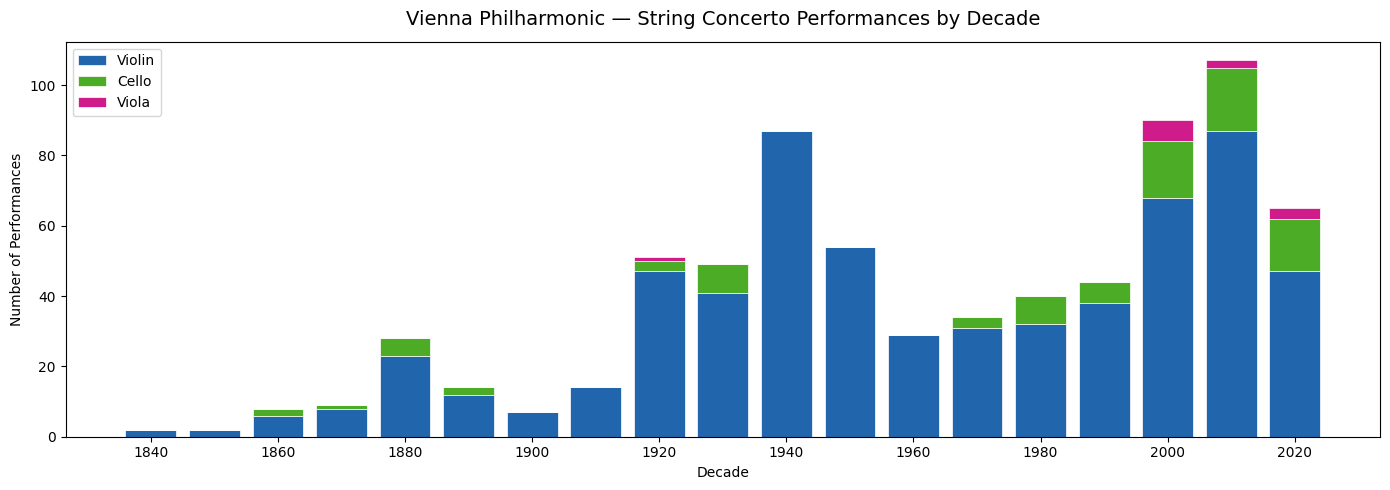

Saved wph_counts_by_decade.png


In [ ]:
#Visualisation of raw counts with stacked bar

fig, ax = plt.subplots(figsize=(14, 5))

colors = {'violin': '#2166ac', 'cello': '#4dac26', 'viola': '#d01c8b'}
bottom = pd.Series(0, index=decade_counts.index)

for instr in ['violin', 'cello', 'viola']:
    if instr in decade_counts.columns:
        ax.bar(decade_counts.index, decade_counts[instr],
               bottom=bottom, label=instr.capitalize(),
               color=colors[instr], width=8, edgecolor='white', linewidth=0.5)
        bottom += decade_counts[instr]

ax.set_title('Vienna Philharmonic — String Concerto Performances by Decade', fontsize=14, pad=12)
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Performances')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mticker.MultipleLocator(20))
plt.tight_layout()
plt.savefig('wph_counts_by_decade.png', dpi=150)
plt.show()
print("Saved wph_counts_by_decade.png")


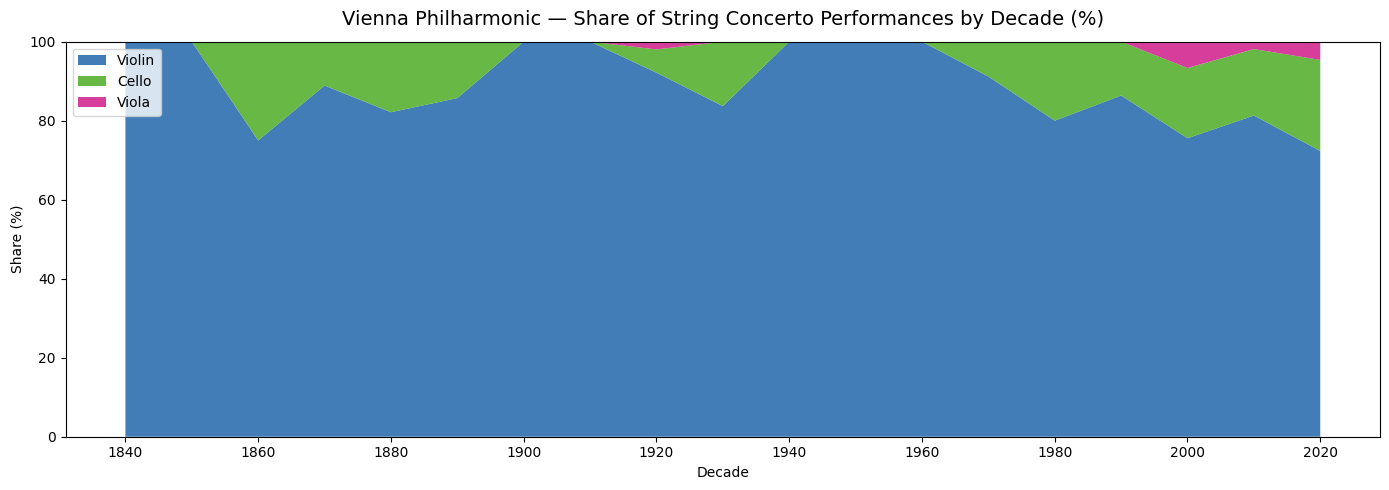

Saved wph_share_by_decade.png


In [ ]:
#Visualisation of proportional area chart

fig, ax = plt.subplots(figsize=(14, 5))

ax.stackplot(decade_pct.index,
             [decade_pct.get('violin', 0),
              decade_pct.get('cello', 0),
              decade_pct.get('viola', 0)],
             labels=['Violin', 'Cello', 'Viola'],
             colors=['#2166ac', '#4dac26', '#d01c8b'],
             alpha=0.85)

ax.set_title('Vienna Philharmonic — Share of String Concerto Performances by Decade (%)',
             fontsize=14, pad=12)
ax.set_xlabel('Decade')
ax.set_ylabel('Share (%)')
ax.set_ylim(0, 100)
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mticker.MultipleLocator(20))
plt.tight_layout()
plt.savefig('wph_share_by_decade.png', dpi=150)
plt.show()
print("Saved wph_share_by_decade.png")

Create Zip File

In [ ]:
import shutil
from google.colab import files

# Zip the entire DataSci112 folder
shutil.make_archive('/content/DataSci112_project', 'zip', '/content/DataSci112')

# Download it to your computer
files.download('/content/DataSci112_project.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>